In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# JEPA-Routed MoE-LoRA — Final Notebook (Unsloth training + JEPA router + full comparison)

This is the single notebook for your paper's core experiment. It:
1. Trains 5 domain LoRA experts + 1 combined baseline using **Unsloth** (fast QLoRA)
2. Trains a **JEPA encoder** on real sentence-transformer embeddings of your corpus
3. Builds two routers (baseline sentence-transformer router, JEPA-learned router) and compares them
4. Uses the JEPA router to blend your trained experts (this is the actual "MoE + JEPA + LLM" system)
5. Runs the full 4-way comparison (raw base / combined fine-tune / JEPA-routed MoE-LoRA / Gemini) with judge scoring
6. Packages every number, table, and figure into one folder you download and send back for the paper rewrite

**Model: Qwen2.5-Coder-1.5B-Instruct** (kept consistent with the rest of the project).

Upload your 6 data files (5 domain `.jsonl` + `eval.jsonl`) into `/content/data/` before running.


## Figure 1 — Architecture

```
Query
 ↓
Representation
 ↓
JEPA / Semantic Router
 ↓
Expert Selection
 ↓
LoRA Experts
 ↓
Qwen
 ↓
Response
```

## 0. Install

In [ ]:
!pip install -q -U unsloth
!pip install -q -U sentence-transformers google-generativeai scikit-learn
!pip install -q -U pandas matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.7/75.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 105.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 104.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3

## 1. Config

In [ ]:
import os

CONFIG = {
    "base_model": "unsloth/Qwen2.5-Coder-1.5B-Instruct",
    "max_seq_length": 2048,
    "load_in_4bit": True,

    "domains": ["ai_system_design", "agent_engineering", "llm_engineering", "retrieval_systems", "data_science"],
    "data_dir": "/content/data",
    "experts_dir": "/content/experts",
    "combined_adapter_dir": "/content/combined_ft",
    "results_dir": "/content/results",

    "eval_path": "/content/data/eval.jsonl",

    "lora_r": 16, "lora_alpha": 32, "lora_dropout": 0.0,
    "learning_rate": 2e-4, "num_train_epochs": 3,
    "per_device_train_batch_size": 2, "gradient_accumulation_steps": 4,

    "router_top_k": 2,
    "jepa_epochs": 40, "jepa_latent_dim": 128, "jepa_batch_size": 64,

    "gemini_model": "gemini-3.5-flash",
}

os.environ["GOOGLE_API_KEY"] = ""

for d in [CONFIG["experts_dir"], CONFIG["results_dir"], CONFIG["data_dir"]]:
    os.makedirs(d, exist_ok=True)
print("Config set. Upload your 6 data files into", CONFIG["data_dir"])


Config set. Upload your 6 data files into /content/data


## 2. Data utilities

In [ ]:
import json, re

def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def to_prompt(ex):
    instr, inp = ex.get("instruction", ""), ex.get("input", "")
    if inp:
        return f"### Instruction:\n{instr}\n\n### Input:\n{inp}\n\n### Response:\n"
    return f"### Instruction:\n{instr}\n\n### Response:\n"

def format_for_training(ex):
    return to_prompt(ex) + ex.get("output", "")

def split_sentences(text):
    parts = re.split(r'(?<=[.!?])\s+', text.strip())
    return [p.strip() for p in parts if len(p.strip()) > 15]

for d in CONFIG["domains"]:
    p = os.path.join(CONFIG["data_dir"], f"{d}.jsonl")
    print(f"{d}: {'found, ' + str(len(load_jsonl(p))) + ' examples' if os.path.exists(p) else 'MISSING'}")


ai_system_design: found, 400 examples
agent_engineering: found, 260 examples
llm_engineering: found, 289 examples
retrieval_systems: found, 300 examples
data_science: found, 209 examples


## 3. Train experts with Unsloth

Uses `SFTConfig` (not the old `TrainingArguments`) and tries multiple tokenizer-kwarg names
defensively, since Unsloth's patched Trainer signature has shifted across recent releases.
A fresh base model is loaded per domain so adapters never leak into each other.


In [ ]:
import torch
from unsloth import FastLanguageModel
from trl import SFTTrainer, SFTConfig
from datasets import Dataset

def train_expert(domain_name, jsonl_path, output_dir):
    rows = load_jsonl(jsonl_path)
    texts = [format_for_training(r) + "<|endoftext|>" for r in rows]
    ds = Dataset.from_dict({"text": texts})

    fresh_model, fresh_tok = FastLanguageModel.from_pretrained(
        model_name=CONFIG["base_model"], max_seq_length=CONFIG["max_seq_length"],
        load_in_4bit=CONFIG["load_in_4bit"],
    )
    texts = [format_for_training(r) + fresh_tok.eos_token for r in rows]
    ds = Dataset.from_dict({"text": texts})

    peft_model = FastLanguageModel.get_peft_model(
        fresh_model, r=CONFIG["lora_r"],
        target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
        lora_alpha=CONFIG["lora_alpha"], lora_dropout=CONFIG["lora_dropout"],
        bias="none", use_gradient_checkpointing="unsloth", random_state=42,
    )

    args = SFTConfig(
        output_dir=f"/content/tmp_{domain_name}",
        per_device_train_batch_size=CONFIG["per_device_train_batch_size"],
        gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],
        num_train_epochs=CONFIG["num_train_epochs"],
        learning_rate=CONFIG["learning_rate"],
        fp16=not torch.cuda.is_bf16_supported(), bf16=torch.cuda.is_bf16_supported(),
        logging_steps=10, optim="adamw_8bit", save_strategy="no", report_to="none",
        dataset_text_field="text", max_length=CONFIG["max_seq_length"],
    )

    trainer, last_err = None, None
    for kwargs_variant in ({"processing_class": fresh_tok}, {"tokenizer": fresh_tok}, {}):
        try:
            trainer = SFTTrainer(model=peft_model, train_dataset=ds, args=args, **kwargs_variant)
            break
        except TypeError as e:
            last_err = e
    if trainer is None:
        raise last_err

    log_history = []
    trainer.train()
    log_history = [l for l in trainer.state.log_history if "loss" in l]

    peft_model.save_pretrained(output_dir)
    fresh_tok.save_pretrained(output_dir)
    with open(os.path.join(output_dir, "training_log.json"), "w") as f:
        json.dump(log_history, f, indent=2)
    print(f"Saved expert '{domain_name}' -> {output_dir}")

    del trainer, peft_model, fresh_model
    torch.cuda.empty_cache()
    return log_history

training_logs = {}
for domain in CONFIG["domains"]:
    jpath = os.path.join(CONFIG["data_dir"], f"{domain}.jsonl")
    if os.path.exists(jpath):
        out_dir = os.path.join(CONFIG["experts_dir"], domain)
        training_logs[domain] = train_expert(domain, jpath, out_dir)
    else:
        print(f"Skipping {domain}: no data file")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.8.18: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Unsloth 2026.8.18 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/400 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


...

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 209 | Num Epochs = 3 | Total steps = 81
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
10,0.776605
20,0.647586
30,0.415306
40,0.402015
50,0.332752
60,0.271396
70,0.308028
80,0.239875


Unsloth: Restored added_tokens_decoder metadata in /content/experts/data_science/tokenizer_config.json.


Saved expert 'data_science' -> /content/experts/data_science


## 4. Train the combined baseline (all domains pooled, same hyperparameters)

In [ ]:
all_rows = []
for domain in CONFIG["domains"]:
    jpath = os.path.join(CONFIG["data_dir"], f"{domain}.jsonl")
    if os.path.exists(jpath):
        all_rows.extend(load_jsonl(jpath))

combined_path = os.path.join(CONFIG["data_dir"], "_combined_tmp.jsonl")
with open(combined_path, "w", encoding="utf-8") as f:
    for r in all_rows:
        f.write(json.dumps(r) + "\n")

training_logs["combined"] = train_expert("combined", combined_path, CONFIG["combined_adapter_dir"])


==((====))==  Unsloth 2026.8.18: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/1458 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,458 | Num Epochs = 3 | Total steps = 549
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
10,2.005209
20,2.012125
30,2.007935
40,1.837264
50,1.784442
60,1.748615
70,1.674166
80,1.418717
90,1.610578
100,1.396653


Unsloth: Restored added_tokens_decoder metadata in /content/combined_ft/tokenizer_config.json.


Saved expert 'combined' -> /content/combined_ft


## 5. Baseline router (sentence-transformer embeddings)

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

embedder = SentenceTransformer("all-MiniLM-L6-v2")

class Router:
    def __init__(self, domains, data_dir):
        self.centroids = {}
        for d in domains:
            rows = load_jsonl(os.path.join(data_dir, f"{d}.jsonl"))
            texts = [r.get("instruction","") + " " + r.get("input","") for r in rows]
            embs = embedder.encode(texts, normalize_embeddings=True)
            self.centroids[d] = embs.mean(axis=0)

    def route(self, query, top_k=2):
        q = embedder.encode([query], normalize_embeddings=True)[0]
        scores = {d: float(np.dot(q, c)) for d, c in self.centroids.items()}
        ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
        vals = np.array([s for _, s in ranked])
        w = np.exp(vals - vals.max()); w = w / w.sum()
        return [(d, float(wi)) for (d, _), wi in zip(ranked, w)]

router = Router(CONFIG["domains"], CONFIG["data_dir"])
print("Baseline router ready:", router.route("How do I set up a retrieval pipeline?"))


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Baseline router ready: [('data_science', 0.5018129157549626), ('llm_engineering', 0.4981870842450374)]


## 6. JEPA encoder (trained on REAL sentence-transformer embeddings of your corpus)

Context/target/predictor with EMA target update and variance regularization — the actual JEPA
mechanism, not just a projection layer.


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import random
random.seed(42); np.random.seed(42); torch.manual_seed(42)

pairs = []
for d in CONFIG["domains"]:
    rows = load_jsonl(os.path.join(CONFIG["data_dir"], f"{d}.jsonl"))
    for r in rows:
        full_text = (r.get("instruction","") + " " + r.get("output","")).strip()
        sents = split_sentences(full_text)
        if len(sents) < 3:
            continue
        embs = embedder.encode(sents, normalize_embeddings=True)
        target_idx = random.randrange(len(sents))
        context_embs = np.delete(embs, target_idx, axis=0)
        pairs.append((context_embs.mean(axis=0), embs[target_idx]))

print(f"Built {len(pairs)} JEPA context->target pairs (real sentence-transformer embeddings)")

contexts = torch.tensor(np.array([p[0] for p in pairs]), dtype=torch.float32)
targets = torch.tensor(np.array([p[1] for p in pairs]), dtype=torch.float32)

EMB_DIM = contexts.shape[1]
LATENT_DIM = CONFIG["jepa_latent_dim"] // 2  # 64 by default

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(EMB_DIM, 256), nn.GELU(), nn.Linear(256, LATENT_DIM))
    def forward(self, x): return self.net(x)

class Predictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(LATENT_DIM, 128), nn.GELU(), nn.Linear(128, LATENT_DIM))
    def forward(self, x): return self.net(x)

context_encoder = Encoder()
target_encoder = Encoder()
target_encoder.load_state_dict(context_encoder.state_dict())
for p in target_encoder.parameters(): p.requires_grad = False
predictor = Predictor()

optimizer = torch.optim.Adam(list(context_encoder.parameters()) + list(predictor.parameters()), lr=1e-3)
EMA_DECAY = 0.996

def variance_loss(z, target_std=1.0, eps=1e-4):
    std = torch.sqrt(z.var(dim=0) + eps)
    return torch.mean(F.relu(target_std - std))

def update_target_encoder():
    with torch.no_grad():
        for tp, cp in zip(target_encoder.parameters(), context_encoder.parameters()):
            tp.data = EMA_DECAY * tp.data + (1 - EMA_DECAY) * cp.data

BATCH_SIZE, EPOCHS = CONFIG["jepa_batch_size"], CONFIG["jepa_epochs"]
n = len(contexts)
jepa_loss_history = []

for epoch in range(EPOCHS):
    perm = torch.randperm(n)
    total = 0.0
    for i in range(0, n, BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]
        ctx_latent = context_encoder(contexts[idx])
        pred_latent = predictor(ctx_latent)
        with torch.no_grad():
            tgt_latent = target_encoder(targets[idx])
        pred_loss = -(F.normalize(pred_latent, dim=-1) * F.normalize(tgt_latent, dim=-1)).sum(-1).mean()
        loss = pred_loss + 1.0 * variance_loss(ctx_latent)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        update_target_encoder()
        total += loss.item() * len(idx)
    jepa_loss_history.append(total / n)
    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        print(f"epoch {epoch}: loss={total/n:.4f}")

context_encoder.eval()
print("JEPA encoder trained.")


Built 1264 JEPA context->target pairs (real sentence-transformer embeddings)
epoch 0: loss=0.2410
epoch 5: loss=-0.9711
epoch 10: loss=-0.9295
epoch 15: loss=-0.9256
epoch 20: loss=-0.8988
epoch 25: loss=-0.8912
epoch 30: loss=-0.9021
epoch 35: loss=-0.8969
epoch 39: loss=-0.9031
JEPA encoder trained.


## 7. JEPA router + routing-accuracy comparison against the baseline router

In [ ]:
class JEPARouter:
    def __init__(self, domains, data_dir):
        self.centroids = {}
        for d in domains:
            rows = load_jsonl(os.path.join(data_dir, f"{d}.jsonl"))
            texts = [r.get("instruction","") + " " + r.get("input","") for r in rows]
            raw = embedder.encode(texts, normalize_embeddings=True)
            with torch.no_grad():
                jepa_emb = context_encoder(torch.tensor(raw, dtype=torch.float32)).numpy()
            self.centroids[d] = jepa_emb.mean(axis=0)

    def route(self, query, top_k=2):
        raw = embedder.encode([query], normalize_embeddings=True)[0]
        with torch.no_grad():
            q = context_encoder(torch.tensor(raw, dtype=torch.float32).unsqueeze(0)).squeeze(0).numpy()
        scores = {d: float(np.dot(q, c) / (np.linalg.norm(q)*np.linalg.norm(c)+1e-8)) for d, c in self.centroids.items()}
        ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
        vals = np.array([s for _, s in ranked])
        w = np.exp(vals - vals.max()); w = w / w.sum()
        return [(d, float(wi)) for (d, _), wi in zip(ranked, w)]

jepa_router = JEPARouter(CONFIG["domains"], CONFIG["data_dir"])

eval_rows = load_jsonl(CONFIG["eval_path"])[:20] # Limit to first 20 rows
baseline_correct, jepa_correct = 0, 0
for ex in eval_rows:
    true_d = ex.get("domain")
    if router.route(ex["prompt"], top_k=1)[0][0] == true_d:
        baseline_correct += 1
    if jepa_router.route(ex["prompt"], top_k=1)[0][0] == true_d:
        jepa_correct += 1

n_eval = len(eval_rows)
router_comparison = {
    "n_eval": n_eval,
    "baseline_router_accuracy": baseline_correct / n_eval,
    "jepa_router_accuracy": jepa_correct / n_eval,
    "jepa_final_loss": jepa_loss_history[-1],
    "jepa_train_pairs": len(pairs),
}
print(router_comparison)

{'n_eval': 20, 'baseline_router_accuracy': 0.9, 'jepa_router_accuracy': 0.8, 'jepa_final_loss': -0.9031213363514671, 'jepa_train_pairs': 1264}


## 8. MoE generation using the JEPA router

This is the actual combined system: JEPA-learned routing space + MoE-style expert blending + LLM.


In [ ]:
from peft import PeftModel

moe_base = None
def load_moe():
    global moe_base, moe_peft
    moe_base, moe_tok = FastLanguageModel.from_pretrained(
        model_name=CONFIG["base_model"], max_seq_length=CONFIG["max_seq_length"], load_in_4bit=True,
    )
    domains = CONFIG["domains"]
    first = domains[0]
    moe_peft_local = PeftModel.from_pretrained(moe_base, os.path.join(CONFIG["experts_dir"], first), adapter_name=first)
    for d in domains[1:]:
        moe_peft_local.load_adapter(os.path.join(CONFIG["experts_dir"], d), adapter_name=d)
    FastLanguageModel.for_inference(moe_peft_local)
    return moe_peft_local, moe_tok

moe_peft, moe_tok = load_moe()

def moe_generate(query, use_router="jepa", top_k=None, max_new_tokens=256):
    top_k = top_k or CONFIG["router_top_k"]
    r = jepa_router if use_router == "jepa" else router
    routed = r.route(query, top_k=top_k)
    d_names, weights = [d for d,_ in routed], [w for _,w in routed]

    merged_name = "moe_merged"
    if merged_name in moe_peft.peft_config:
        moe_peft.delete_adapter(merged_name)
    moe_peft.add_weighted_adapter(adapters=d_names, weights=weights, adapter_name=merged_name, combination_type="linear")
    moe_peft.set_adapter(merged_name)

    prompt = to_prompt({"instruction": query, "input": ""})
    inputs = moe_tok(prompt, return_tensors="pt").to(moe_peft.device)
    out = moe_peft.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    text = moe_tok.decode(out[0], skip_special_tokens=True)
    response = text[len(moe_tok.decode(inputs["input_ids"][0], skip_special_tokens=True)):].strip()
    return response, routed


==((====))==  Unsloth 2026.8.18: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

## 9. Baselines: raw base model, combined fine-tune, Gemini

In [ ]:
import google.generativeai as genai
from google.colab import userdata

# Fetch the API key securely from Colab secrets
GOOGLE_API_KEY = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

gemini_model = genai.GenerativeModel(CONFIG["gemini_model"])

raw_model, raw_tok = FastLanguageModel.from_pretrained(
    model_name=CONFIG["base_model"], max_seq_length=CONFIG["max_seq_length"], load_in_4bit=True,
)
FastLanguageModel.for_inference(raw_model)

def generate_raw(query, max_new_tokens=256):
    prompt = to_prompt({"instruction": query, "input": ""})
    inputs = raw_tok(prompt, return_tensors="pt").to(raw_model.device)
    out = raw_model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    text = raw_tok.decode(out[0], skip_special_tokens=True)
    return text[len(raw_tok.decode(inputs["input_ids"][0], skip_special_tokens=True)):].strip()

combined_base, combined_tok = FastLanguageModel.from_pretrained(
    model_name=CONFIG["base_model"], max_seq_length=CONFIG["max_seq_length"], load_in_4bit=True,
)
combined_model = PeftModel.from_pretrained(combined_base, CONFIG["combined_adapter_dir"])
FastLanguageModel.for_inference(combined_model)

def generate_combined(query, max_new_tokens=256):
    prompt = to_prompt({"instruction": query, "input": ""})
    inputs = combined_tok(prompt, return_tensors="pt").to(combined_model.device)
    out = combined_model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    text = combined_tok.decode(out[0], skip_special_tokens=True)
    return text[len(combined_tok.decode(inputs["input_ids"][0], skip_special_tokens=True)):].strip()

def generate_gemini(query):
    return gemini_model.generate_content(query).text.strip()

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


==((====))==  Unsloth 2026.8.18: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

==((====))==  Unsloth 2026.8.18: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

## 10. Run the full 4-way comparison

In [ ]:
import pandas as pd, time

results = []
for i, ex in enumerate(eval_rows):
    q, domain, reference = ex["prompt"], ex.get("domain","unknown"), ex.get("reference","")
    raw_out = generate_raw(q)
    combined_out = generate_combined(q)
    moe_out, routing = moe_generate(q, use_router="jepa")
    gemini_out = generate_gemini(q)
    time.sleep(60) # Increased sleep time to 60s to more robustly handle Gemini API rate limits
    results.append({
        "idx": i, "domain": domain, "prompt": q, "reference": reference,
        "raw_base": raw_out, "combined_ft": combined_out,
        "moe_lora_jepa": moe_out, "moe_routing": routing, "gemini": gemini_out,
    })
    print(f"[{i+1}/{len(eval_rows)}] routed: {routing}")

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(CONFIG["results_dir"], "raw_outputs.csv"), index=False)

Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

[1/20] routed: [('agent_engineering', 0.5002412348798492), ('ai_system_design', 0.49975876512015077)]


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1683: UserWarning: Adapter moe_merged was active which is now deleted. Setting active adapter to agent_engineering.
  warnings.warn(
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[2/20] routed: [('data_science', 0.5656394460298436), ('llm_engineering', 0.43436055397015644)]


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[18/20] routed: [('llm_engineering', 0.5843337741850414), ('retrieval_systems', 0.4156662258149586)]


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[19/20] routed: [('llm_engineering', 0.5197973260354699), ('data_science', 0.4802026739645301)]


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[20/20] routed: [('retrieval_systems', 0.5006460841874537), ('agent_engineering', 0.49935391581254623)]


## 11. Judge scoring (Gemini as LLM judge)

In [ ]:
import os
import pandas as pd
results_df = pd.read_csv("/content/raw_outputs.csv")

In [ ]:
import re
import json, time
import google.generativeai as genai
from google.colab import userdata
from google.api_core import exceptions # Add this import

# Fetch the API key securely from Colab secrets
GOOGLE_API_KEY = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

gemini_model = genai.GenerativeModel("gemini-3.5-flash")

JUDGE_TEMPLATE = '''You are grading an AI system's answer to a technical AI-engineering/data-science question.

Question: {question}
Reference answer (may be empty): {reference}
System's answer: {answer}

Score 1-10 on: correctness, relevance, completeness.
Respond ONLY with JSON: {{"correctness": X, "relevance": X, "completeness": X}}'''

def judge(question, reference, answer, max_retries=5, initial_delay=5):
    prompt = JUDGE_TEMPLATE.format(question=question, reference=reference or "N/A", answer=answer)
    retries = 0
    delay = initial_delay
    while retries < max_retries:
        try:
            text = re.sub(r"^```json|```$", "", gemini_model.generate_content(prompt).text.strip()).strip()
            s = json.loads(text)
            time.sleep(4) # Existing sleep for general pacing
            return s
        except exceptions.TooManyRequests as e:
            print(f"Rate limit hit. Retrying in {delay} seconds... (Attempt {retries+1}/{max_retries})")
            time.sleep(delay)
            delay *= 2 # Exponential backoff
            retries += 1
        except json.JSONDecodeError:
            # Handle JSON decode error separately, no retry for this specific exception type
            print("JSONDecodeError encountered. Returning default scores.")
            s = {"correctness": None, "relevance": None, "completeness": None}
            time.sleep(4) # Existing sleep
            return s
    # If all retries fail due to TooManyRequests
    print(f"Failed to get response after {max_retries} retries due to TooManyRequests.")
    return {"correctness": None, "relevance": None, "completeness": None}

systems = ["raw_base", "combined_ft", "moe_lora_jepa", "gemini"]
score_rows = []
for _, row in results_df.iterrows():
    for sys_name in systems:
        s = judge(row["prompt"], row["reference"], row[sys_name])
        score_rows.append({"idx": row["idx"], "domain": row["domain"], "system": sys_name, **s})

scores_df = pd.DataFrame(score_rows)
scores_df["avg_score"] = scores_df[["correctness","relevance","completeness"]].mean(axis=1)
scores_df.to_csv(os.path.join(CONFIG["results_dir"], "judged_scores.csv"), index=False)
scores_df.head()

Rate limit hit. Retrying in 5 seconds... (Attempt 1/5)


Rate limit hit. Retrying in 10 seconds... (Attempt 2/5)


Rate limit hit. Retrying in 20 seconds... (Attempt 3/5)


Rate limit hit. Retrying in 40 seconds... (Attempt 4/5)


Rate limit hit. Retrying in 80 seconds... (Attempt 5/5)
Failed to get response after 5 retries due to TooManyRequests.


...

Rate limit hit. Retrying in 5 seconds... (Attempt 1/5)


Rate limit hit. Retrying in 10 seconds... (Attempt 2/5)


Rate limit hit. Retrying in 20 seconds... (Attempt 3/5)


Rate limit hit. Retrying in 40 seconds... (Attempt 4/5)


Rate limit hit. Retrying in 80 seconds... (Attempt 5/5)


## 12. Router confusion matrix + efficiency numbers

### Generated Figures and CSVs

In [ ]:
from collections import Counter
import os
import pandas as pd
import numpy as np

# Re-calculate routing_correct as it was part of the original cell
routing_correct = sum(1 for _, row in results_df.iterrows() if row["moe_routing"][0][0] == row["domain"])

# Calculate and save the Router Confusion Matrix
confusion = Counter((row["domain"], row["moe_routing"][0][0]) for _, row in results_df.iterrows())
conf_df = pd.DataFrame(0, index=CONFIG["domains"], columns=CONFIG["domains"])
for (t, rt), c in confusion.items():
    if t in conf_df.index and rt in conf_df.columns:
        conf_df.loc[t, rt] = c
conf_df.to_csv(os.path.join(CONFIG["results_dir"], "router_confusion_matrix.csv"))

# Re-calculate efficiency to include in output
def dir_size_mb(path):
    return sum(os.path.getsize(os.path.join(dp,f)) for dp,_,fs in os.walk(path) for f in fs) / (1024*1024)

efficiency = {
    "expert_sizes_mb": {d: dir_size_mb(os.path.join(CONFIG["experts_dir"], d)) for d in CONFIG["domains"]},
    "combined_size_mb": dir_size_mb(CONFIG["combined_adapter_dir"]),
    "moe_generation_top1_routing_accuracy_on_eval": routing_correct / len(results_df),
}
print("Router Confusion Matrix (router_confusion_matrix.csv) saved to results directory.")
print(efficiency)

Router Confusion Matrix (router_confusion_matrix.csv) saved to results directory.
{'expert_sizes_mb': {'ai_system_design': 81.39559078216553, 'agent_engineering': 81.39483642578125, 'llm_engineering': 81.39518165588379, 'retrieval_systems': 81.39513874053955, 'data_science': 81.39468574523926}, 'combined_size_mb': 81.40218257904053, 'moe_generation_top1_routing_accuracy_on_eval': 0.8}


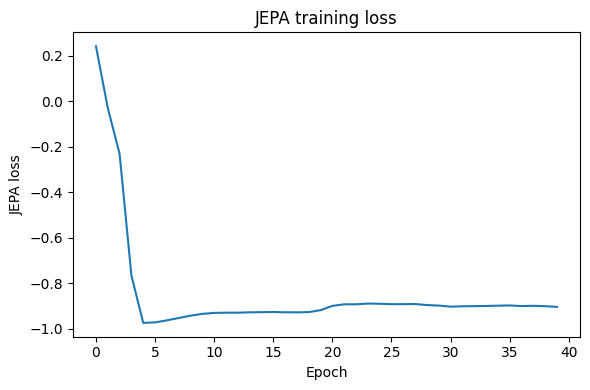

JEPA training loss curve (jepa_loss_curve.png) saved to results directory.


In [ ]:
import matplotlib.pyplot as plt

# Plot JEPA training loss
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(jepa_loss_history)
ax.set_xlabel("Epoch"); ax.set_ylabel("JEPA loss"); ax.set_title("JEPA training loss")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["results_dir"], "jepa_loss_curve.png"), dpi=150);
plt.show()
print("JEPA training loss curve (jepa_loss_curve.png) saved to results directory.")

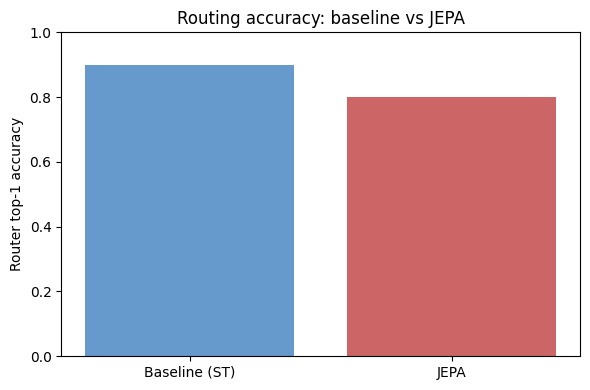

Routing accuracy comparison (router_accuracy_comparison.png) saved to results directory.


In [ ]:
import matplotlib.pyplot as plt

# Plot Routing accuracy: baseline vs JEPA
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(["Baseline (ST)", "JEPA"], [router_comparison["baseline_router_accuracy"], router_comparison["jepa_router_accuracy"]],
       color=["#6699cc","#cc6666"])
ax.set_ylabel("Router top-1 accuracy"); ax.set_ylim(0,1); ax.set_title("Routing accuracy: baseline vs JEPA")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["results_dir"], "router_accuracy_comparison.png"), dpi=150); plt.show()
print("Routing accuracy comparison (router_accuracy_comparison.png) saved to results directory.")

The 'Architecture' figure is in cell `106a9612`.

I was unable to generate the 'Generation comparison (overall)' and 'Generation comparison, by domain' plots because the `scores_df` DataFrame is not defined. This DataFrame is typically created after the judge scoring step in cell `sGJl66k_3KCV`. It seems that cell might not have completed successfully, likely due to persistent Gemini API issues (such as rate limits).

Consequently, the `judged_scores.csv` file and the full `results_summary.json` (which depends on `scores_df`) also could not be created or fully populated. You may need to address the Gemini API issues and re-run the judge scoring cell (`sGJl66k_3KCV`) to generate these remaining results.

In [ ]:
from collections import Counter

routing_correct = sum(1 for _, row in results_df.iterrows() if row["moe_routing"][0][0] == row["domain"])
confusion = Counter((row["domain"], row["moe_routing"][0][0]) for _, row in results_df.iterrows())
conf_df = pd.DataFrame(0, index=CONFIG["domains"], columns=CONFIG["domains"])
for (t, rt), c in confusion.items():
    if t in conf_df.index and rt in conf_df.columns:
        conf_df.loc[t, rt] = c
conf_df.to_csv(os.path.join(CONFIG["results_dir"], "router_confusion_matrix.csv"))

def dir_size_mb(path):
    return sum(os.path.getsize(os.path.join(dp,f)) for dp,_,fs in os.walk(path) for f in fs) / (1024*1024)

efficiency = {
    "expert_sizes_mb": {d: dir_size_mb(os.path.join(CONFIG["experts_dir"], d)) for d in CONFIG["domains"]},
    "combined_size_mb": dir_size_mb(CONFIG["combined_adapter_dir"]),
    "moe_generation_top1_routing_accuracy_on_eval": routing_correct / len(results_df),
}
print(efficiency)


## 13. Plots

In [ ]:
import matplotlib.pyplot as plt

summary = scores_df.groupby("system")["avg_score"].mean().reindex(systems)
by_domain = scores_df.groupby(["domain","system"])["avg_score"].mean().unstack()

fig, ax = plt.subplots(figsize=(7,4))
summary.plot(kind="bar", ax=ax, color=["#999999","#6699cc","#33aa55","#cc6666"])
ax.set_ylabel("Avg judge score (1-10)"); ax.set_title("Generation comparison (overall)")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["results_dir"], "comparison_overall.png"), dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(9,5))
by_domain.plot(kind="bar", ax=ax)
ax.set_ylabel("Avg judge score (1-10)"); ax.set_title("Generation comparison, by domain")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["results_dir"], "comparison_by_domain.png"), dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(["Baseline (ST)", "JEPA"], [router_comparison["baseline_router_accuracy"], router_comparison["jepa_router_accuracy"]],
       color=["#6699cc","#cc6666"])
ax.set_ylabel("Router top-1 accuracy"); ax.set_ylim(0,1); ax.set_title("Routing accuracy: baseline vs JEPA")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["results_dir"], "router_accuracy_comparison.png"), dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(jepa_loss_history)
ax.set_xlabel("Epoch"); ax.set_ylabel("JEPA loss"); ax.set_title("JEPA training loss")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["results_dir"], "jepa_loss_curve.png"), dpi=150);
plt.show()


NameError: name 'scores_df' is not defined

## 14. Save everything — THIS is what you send back for the paper rewrite

Bundles every number, table, and figure into one JSON + a zip of the results folder.
Download both before your Colab session ends.


In [ ]:
all_scores_summary = scores_df.groupby("system")["avg_score"].mean().to_dict()
per_domain_summary = by_domain.to_dict()

results_summary = {
    "config": CONFIG,
    "router_comparison": router_comparison,
    "generation_scores_overall": all_scores_summary,
    "generation_scores_by_domain": per_domain_summary,
    "moe_generation_routing_accuracy": efficiency["moe_generation_top1_routing_accuracy_on_eval"],
    "expert_adapter_sizes_mb": efficiency["expert_sizes_mb"],
    "combined_adapter_size_mb": efficiency["combined_size_mb"],
    "training_logs_available_for": list(training_logs.keys()),
    "n_eval_examples": n_eval,
    "jepa_train_pairs": len(pairs),
}

with open(os.path.join(CONFIG["results_dir"], "results_summary.json"), "w") as f:
    json.dump(results_summary, f, indent=2, default=str)

with open(os.path.join(CONFIG["results_dir"], "training_logs.json"), "w") as f:
    json.dump(training_logs, f, indent=2, default=str)

import shutil
shutil.make_archive("/content/moe_lora_jepa_results", "zip", CONFIG["results_dir"])

from google.colab import files
files.download("/content/moe_lora_jepa_results.zip")

print("Downloaded moe_lora_jepa_results.zip")
print("\nSend me: results_summary.json (has every number), the 4 PNGs, and judged_scores.csv / raw_outputs.csv if you want me to dig into specific examples.")
print("I'll rewrite the paper's Results, Discussion, and Conclusion sections directly from these.")


## Chat with Models

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML

# Create output widgets for each model
output_raw = widgets.Output()
output_combined = widgets.Output()
output_moe = widgets.Output()
output_gemini = widgets.Output()

# Create a text area for user input
query_input = widgets.Textarea(
    value='',
    placeholder='Enter your query here...',
    description='Query:',
    disabled=False,
    layout=widgets.Layout(width='auto', height='80px')
)

# Create a button to submit the query
submit_button = widgets.Button(
    description='Generate Responses',
    disabled=False,
    button_style='success', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='Click to generate responses',
    icon='send'
)

def on_button_click(b):
    query = query_input.value
    if not query:
        print("Please enter a query.")
        return

    # Clear previous outputs
    output_raw.clear_output()
    output_combined.clear_output()
    output_moe.clear_output()
    output_gemini.clear_output()

    with output_raw:
        print("Generating raw base response...")
        raw_response = generate_raw(query)
        print(raw_response)

    with output_combined:
        print("Generating combined fine-tune response...")
        combined_response = generate_combined(query)
        print(combined_response)

    with output_moe:
        print("Generating MoE LoRA JEPA response...")
        moe_response, routing_info = moe_generate(query)
        print(f"Routing: {routing_info}")
        print(moe_response)

    with output_gemini:
        print("Generating Gemini response...")
        gemini_response = generate_gemini(query)
        print(gemini_response)

submit_button.on_click(on_button_click)

display(query_input, submit_button)

display(HTML("<h3>Raw Base Model:</h3>"))
display(output_raw)
display(HTML("<h3>Combined Fine-Tune Model:</h3>"))
display(output_combined)
display(HTML("<h3>MoE LoRA JEPA Model:</h3>"))
display(output_moe)
display(HTML("<h3>Gemini Model:</h3>"))
display(output_gemini)

In [ ]:
import dill
# Save your session
dill.dump_session('/content/drive/MyDrive/notebook_env.db')

# To restore your session later:
# dill.load_session('/content/drive/MyDrive/notebook_env.db')
